# Accent Coach — Phase 0 Validation

Three comparisons, all using the same 50 calibration sentences:

| | Speaker | Reference | Target |
|---|---|---|---|
| **A** | IndexTTS BC synth | RP norms | ≥ 85 |
| **B** | You | RP norms | ≤ 65 |
| **C** | You | IndexTTS BC synth | within ±5 of B |

Vowel scoring uses **Lobanov normalisation** (z-scores per speaker) so that BC's
naturally lower vocal pitch doesn't penalise him in raw-Hz comparisons against RP norms.

**Two-pass structure**: alignment + formant extraction runs first for all sentences,
then Lobanov params are computed from the full token pool, then scoring happens.
Re-run top-to-bottom as more BC files finish generating.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130

from accent_coach.calibration.sentences import CALIBRATION_SENTENCES, get_by_id
from accent_coach.pipeline.features import analyse_audio
from accent_coach.comparison.scoring import compare
from accent_coach.reference.rp_norms import get_rp_norms, RP_VOWEL_F1_F2_MALE
from accent_coach.reference.normalize import compute_lobanov_params, rp_lobanov_params

BC_DIR   = Path("../tts_output/accent_coach/bc_cal_50")
USER_DIR = Path("../tts_output/accent_coach/users/owner")

def bc_wav(sid):  return BC_DIR / f"indextts_cal_{sid:03d}.wav"
def user_wav(sid):
    m = sorted(USER_DIR.glob(f"{sid:03d}_*.wav"))
    return m[0] if m else None

bc_done   = sum(1 for s in CALIBRATION_SENTENCES if bc_wav(s.id).exists())
user_done = sum(1 for s in CALIBRATION_SENTENCES if user_wav(s.id) is not None)
print(f"BC synth ready : {bc_done} / 50")
print(f"Your recordings: {user_done} / 50")

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.

BC synth ready : 50 / 50
Your recordings: 50 / 50


In [2]:
# ── Pass 1: extract features for every available sentence ─────────
# Results cached as dicts so Pass 2 can score without re-running alignment.

bc_analyses   = {}   # sid → (SentenceAnalysis, audio, sr)
user_analyses = {}   # sid → (SentenceAnalysis, audio, sr)

def load_analysis(wav, sid):
    meta = get_by_id(sid)
    analysis = analyse_audio(wav, meta.text, meta)
    audio, sr = sf.read(str(wav), always_2d=False)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    return analysis, audio.astype("float32"), sr

for s in CALIBRATION_SENTENCES:
    if bc_wav(s.id).exists():
        try:
            bc_analyses[s.id] = load_analysis(bc_wav(s.id), s.id)
        except Exception as e:
            print(f"  BC  sid={s.id} SKIP: {e}")
    w = user_wav(s.id)
    if w is not None:
        try:
            user_analyses[s.id] = load_analysis(w, s.id)
        except Exception as e:
            print(f"  You sid={s.id} SKIP: {e}")

print(f"Pass 1 done — BC: {len(bc_analyses)} sentences, You: {len(user_analyses)} sentences")

Pass 1 done — BC: 50 sentences, You: 50 sentences


In [3]:
# ── Compute Lobanov normalisation params ──────────────────────────
# Collect every vowel token from every sentence for each speaker,
# then compute grand mean/SD. This is the correct pool size for Lobanov.

bc_vowels_all   = [v for a, _, _ in bc_analyses.values()   for v in a.vowels]
user_vowels_all = [v for a, _, _ in user_analyses.values() for v in a.vowels]

bc_lob   = compute_lobanov_params(bc_vowels_all)   if bc_vowels_all   else None
user_lob = compute_lobanov_params(user_vowels_all) if user_vowels_all else None

# RP reference params — computed from the norms table itself
mean_f0_user = float(np.mean([v.pitch_mean for v in user_vowels_all if v.pitch_mean > 50] or [120.]))
rp_norms     = get_rp_norms(mean_f0_user)
rp_lob       = rp_lobanov_params(rp_norms)

print(f"BC   Lobanov params: F1 mean={bc_lob.mean_f1:.0f} sd={bc_lob.sd_f1:.0f}  "
      f"F2 mean={bc_lob.mean_f2:.0f} sd={bc_lob.sd_f2:.0f}" if bc_lob else "BC: no vowels")
print(f"You  Lobanov params: F1 mean={user_lob.mean_f1:.0f} sd={user_lob.sd_f1:.0f}  "
      f"F2 mean={user_lob.mean_f2:.0f} sd={user_lob.sd_f2:.0f}" if user_lob else "You: no vowels")
print(f"RP   Lobanov params: F1 mean={rp_lob.mean_f1:.0f} sd={rp_lob.sd_f1:.0f}  "
      f"F2 mean={rp_lob.mean_f2:.0f} sd={rp_lob.sd_f2:.0f}")
print(f"\nVowel tokens — BC: {len(bc_vowels_all)}  You: {len(user_vowels_all)}")

BC   Lobanov params: F1 mean=423 sd=167  F2 mean=1489 sd=358
You  Lobanov params: F1 mean=489 sd=148  F2 mean=1596 sd=395
RP   Lobanov params: F1 mean=523 sd=144  F2 mean=1297 sd=419

Vowel tokens — BC: 399  You: 491


In [4]:
# ── Pass 2: score every sentence using Lobanov-normalised vowels ──

def make_row(result, sid):
    return {
        "sid": sid,
        "composite": result.composite_score,
        **result.skill_scores,
        "npvi":        result.rhythm_breakdown.npvi,
        "diagnostics": result.vowel_diagnostics,
    }

exp_a, exp_b, exp_c = [], [], []

for sid, (a, audio, sr) in bc_analyses.items():
    mean_f0 = float(np.mean([v.pitch_mean for v in a.vowels if v.pitch_mean > 50] or [100.]))
    r = compare(a, audio, sr, reference_norms=rp_norms,
                speaker_lobanov=bc_lob, ref_lobanov=rp_lob)
    exp_a.append(make_row(r, sid))

for sid, (a, audio, sr) in user_analyses.items():
    r = compare(a, audio, sr, reference_norms=rp_norms,
                speaker_lobanov=user_lob, ref_lobanov=rp_lob)
    exp_b.append(make_row(r, sid))

for sid in set(user_analyses) & set(bc_analyses):
    u_a, u_audio, u_sr = user_analyses[sid]
    b_a, _,      _     = bc_analyses[sid]
    # Lobanov for user vs BC: use each speaker's own params
    r = compare(u_a, u_audio, u_sr, target=b_a,
                speaker_lobanov=user_lob, ref_lobanov=bc_lob)
    exp_c.append(make_row(r, sid))

mean_a = np.mean([r["composite"] for r in exp_a]) if exp_a else float("nan")
mean_b = np.mean([r["composite"] for r in exp_b]) if exp_b else float("nan")
mean_c = np.mean([r["composite"] for r in exp_c]) if exp_c else float("nan")
diff_bc = mean_c - mean_b

print(f"Exp A  BC synth vs RP  : {mean_a:.1f}  (target ≥ 85)")
print(f"Exp B  You     vs RP  : {mean_b:.1f}  (target ≤ 65)")
print(f"Exp C  You     vs BC  : {mean_c:.1f}  (target B ± 5, diff={diff_bc:+.1f})")

Exp A  BC synth vs RP  : 46.5  (target ≥ 85)
Exp B  You     vs RP  : 46.3  (target ≤ 65)
Exp C  You     vs BC  : 62.6  (target B ± 5, diff=+16.3)


In [5]:
import pandas as pd
skills = ["vowels", "consonants", "aspiration", "rhythm", "stress", "intonation"]
rows = []
for label, results, target in [
    ("A: BC synth vs RP  [≥ 85]",  exp_a, True),
    ("B: You vs RP       [≤ 65]",  exp_b, True),
    ("C: You vs BC synth [≈ B±5]", exp_c, True),
]:
    if not results: continue
    row = {"Experiment": label, "n": len(results),
           "Composite": np.mean([r["composite"] for r in results])}
    for sk in skills:
        row[sk.capitalize()] = np.mean([r.get(sk, 0) for r in results])
    row["nPVI"] = np.mean([r["npvi"] for r in results])
    rows.append(row)

df = pd.DataFrame(rows).set_index("Experiment")
df.style.format("{:.1f}", subset=[c for c in df.columns if c != "n"]) \
        .format("{:.0f}", subset=["n"]) \
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=100,
                             subset=["Composite"] + [s.capitalize() for s in skills])

,n,Composite,Vowels,Consonants,Aspiration,Rhythm,Stress,Intonation,nPVI
Experiment,,,,,,,,,
A: BC synth vs RP [≥ 85],50,46.5,45.8,70.0,35.0,29.2,16.7,82.6,37.7
B: You vs RP [≤ 65],50,46.3,46.2,70.0,27.7,33.9,16.8,83.2,41.4
C: You vs BC synth [≈ B±5],50,62.6,45.9,70.0,42.8,65.4,70.8,91.7,41.4


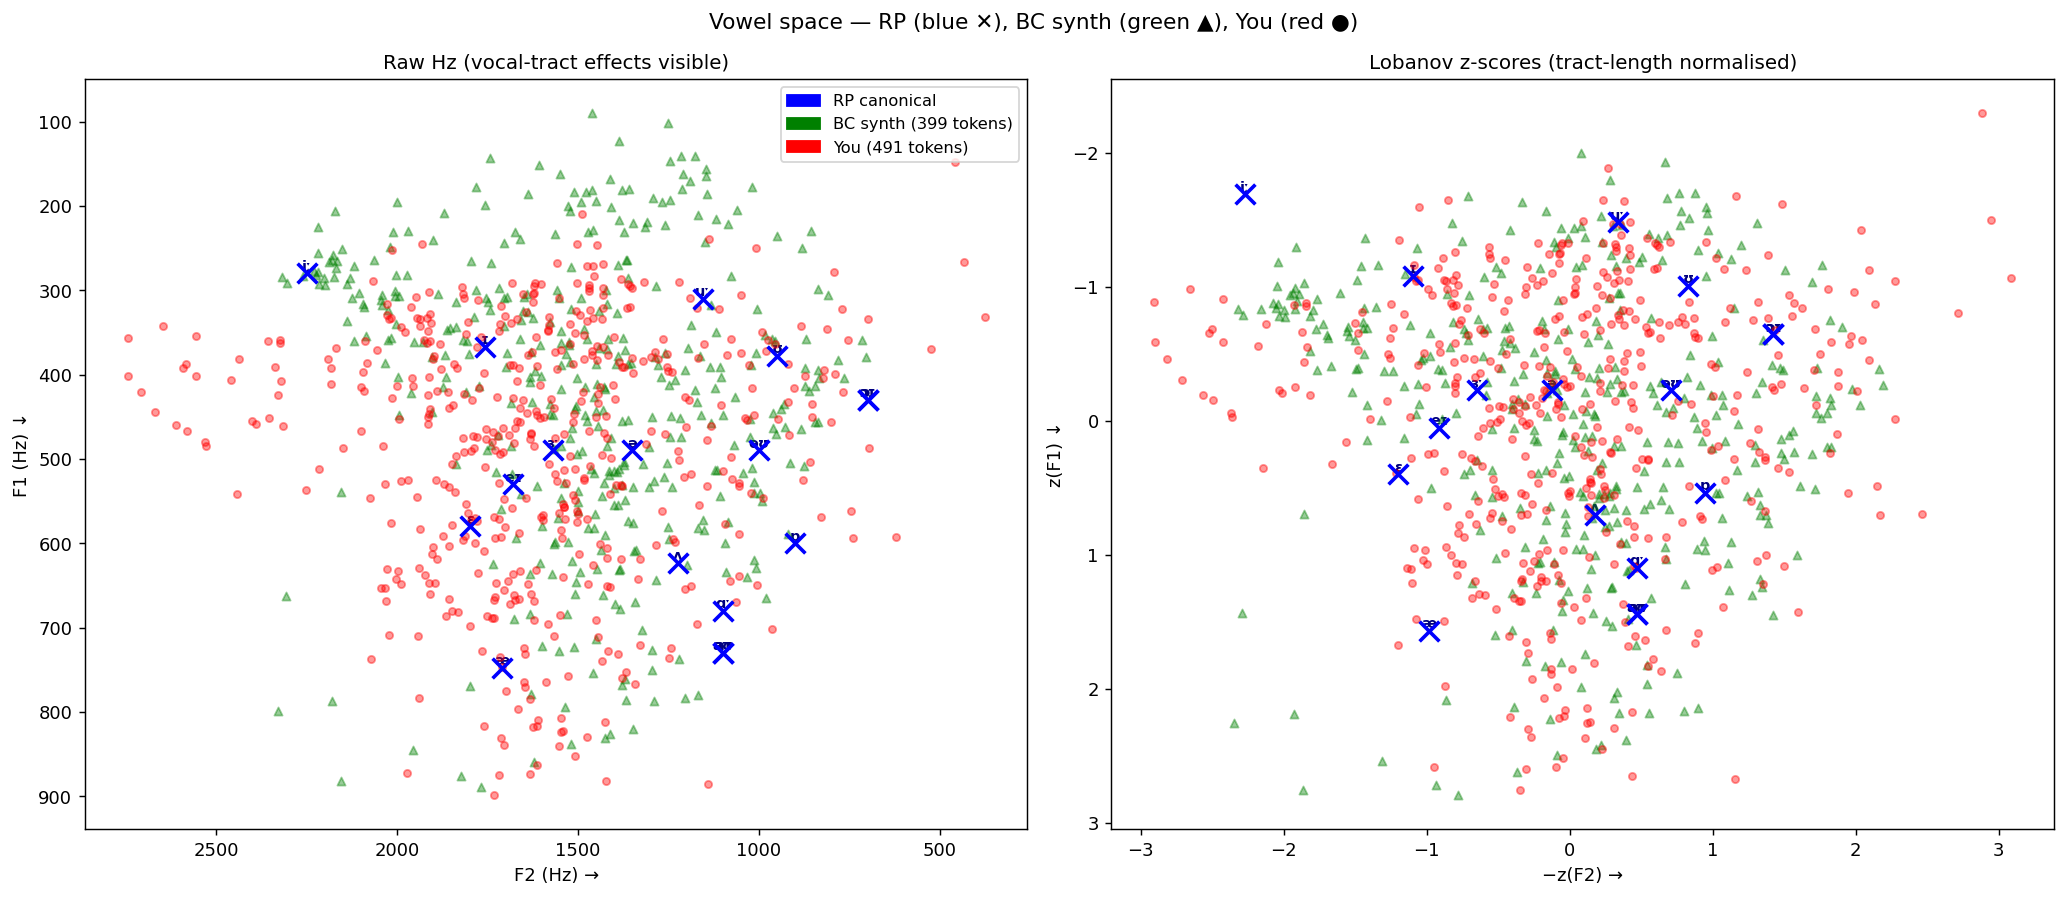

In [6]:
# ── Three-way vowel scatter in Lobanov z-score space ─────────────
# Each speaker's vowels are normalised by their own mean/SD,
# so the three clouds should be comparable regardless of vocal-tract size.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, title, use_lobanov in [
    (axes[0], "Raw Hz (vocal-tract effects visible)", False),
    (axes[1], "Lobanov z-scores (tract-length normalised)", True),
]:
    def point(v, lob):
        if use_lobanov and lob:
            return lob.normalise(v.f1, v.f2)
        return v.f2, v.f1   # x=F2, y=F1 for vowel chart convention

    # RP reference
    for ph, (f1, f2) in rp_norms.items():
        if use_lobanov:
            rz1, rz2 = rp_lob.normalise(f1, f2)
            x_rp, y_rp = -rz2, rz1   # F2 → x (inverted), F1 → y
        else:
            x_rp, y_rp = f2, f1
        ax.scatter(x_rp, y_rp, marker="x", s=120, color="blue", zorder=5, linewidths=2)
        ax.annotate(ph, (x_rp, y_rp), fontsize=8, color="navy",
                    ha="center", va="bottom", fontweight="bold")

    # BC synth
    for v in bc_vowels_all:
        if use_lobanov and bc_lob:
            z1, z2 = bc_lob.normalise(v.f1, v.f2)
            ax.scatter(-z2, z1, marker="^", s=20, alpha=0.4, color="green", zorder=3)
        else:
            ax.scatter(v.f2, v.f1, marker="^", s=20, alpha=0.4, color="green", zorder=3)

    # User
    for v in user_vowels_all:
        if use_lobanov and user_lob:
            z1, z2 = user_lob.normalise(v.f1, v.f2)
            ax.scatter(-z2, z1, marker="o", s=16, alpha=0.4, color="red", zorder=4)
        else:
            ax.scatter(v.f2, v.f1, marker="o", s=16, alpha=0.4, color="red", zorder=4)

    if use_lobanov:
        ax.set_xlabel("−z(F2) →", fontsize=10)
        ax.set_ylabel("z(F1) ↓", fontsize=10)
        ax.invert_yaxis()
    else:
        ax.set_xlabel("F2 (Hz) →", fontsize=10)
        ax.set_ylabel("F1 (Hz) ↓", fontsize=10)
        ax.invert_yaxis()
        ax.invert_xaxis()
    ax.set_title(title, fontsize=11)

legend = [
    mpatches.Patch(color="blue",  label="RP canonical"),
    mpatches.Patch(color="green", label=f"BC synth ({len(bc_vowels_all)} tokens)"),
    mpatches.Patch(color="red",   label=f"You ({len(user_vowels_all)} tokens)"),
]
axes[0].legend(handles=legend, fontsize=9)
plt.suptitle("Vowel space — RP (blue ✕), BC synth (green ▲), You (red ●)", fontsize=12)
plt.tight_layout()
plt.show()

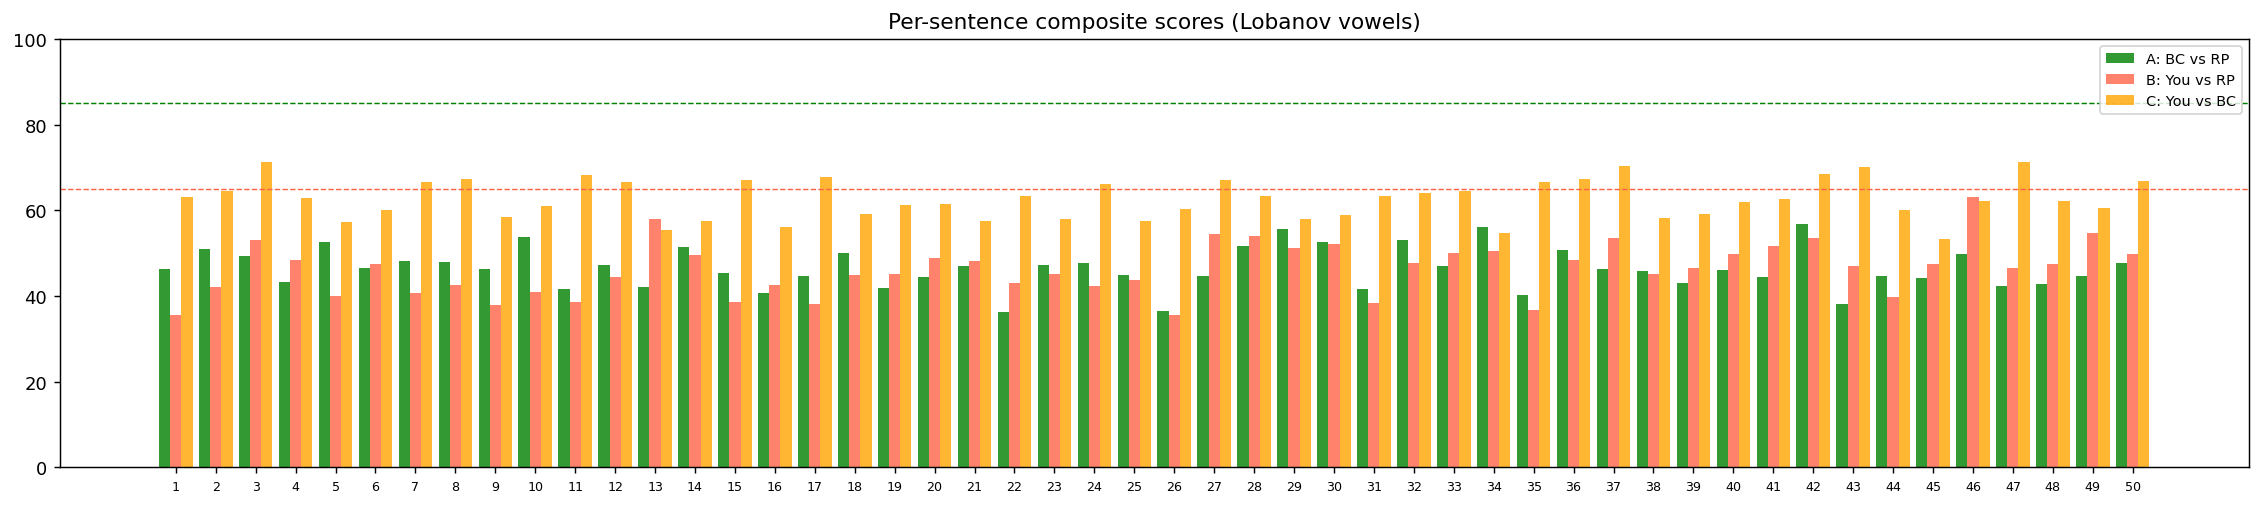

In [7]:
# ── Per-sentence bar chart ────────────────────────────────────────
all_sids = sorted({r["sid"] for r in exp_a + exp_b + exp_c})
a_map = {r["sid"]: r["composite"] for r in exp_a}
b_map = {r["sid"]: r["composite"] for r in exp_b}
c_map = {r["sid"]: r["composite"] for r in exp_c}

x = np.arange(len(all_sids)); w = 0.28
fig, ax = plt.subplots(figsize=(max(12, len(all_sids) * 0.35), 4))
if a_map: ax.bar(x - w, [a_map.get(s, 0) for s in all_sids], w, label="A: BC vs RP",  color="green",  alpha=0.8)
if b_map: ax.bar(x,     [b_map.get(s, 0) for s in all_sids], w, label="B: You vs RP", color="tomato", alpha=0.8)
if c_map: ax.bar(x + w, [c_map.get(s, 0) for s in all_sids], w, label="C: You vs BC", color="orange", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(all_sids, fontsize=7)
ax.set_ylim(0, 100)
ax.axhline(65, color="tomato", linestyle="--", linewidth=0.8)
ax.axhline(85, color="green",  linestyle="--", linewidth=0.8)
ax.legend(fontsize=8); ax.set_title("Per-sentence composite scores (Lobanov vowels)")
plt.tight_layout(); plt.show()

In [8]:
# ── Articulatory diagnostics: You vs RP ──────────────────────────
from collections import defaultdict

ph_f1_diff: dict = defaultdict(list)
ph_f2_diff: dict = defaultdict(list)
for row in exp_b:
    for d in row["diagnostics"]:
        ph_f1_diff[d.phoneme].append(d.user_f1 - d.target_f1)
        ph_f2_diff[d.phoneme].append(d.user_f2 - d.target_f2)

print("Your vowel deviations from RP — mean across all sentences\n")
print(f"  {'Ph':>5}   {'ΔF1':>8}   {'ΔF2':>8}   Advice")
print("  " + "-" * 62)
for ph in sorted(ph_f1_diff,
                 key=lambda p: abs(np.mean(ph_f1_diff[p])) + abs(np.mean(ph_f2_diff[p])),
                 reverse=True):
    df1 = np.mean(ph_f1_diff[ph])
    df2 = np.mean(ph_f2_diff[ph])
    n   = len(ph_f1_diff[ph])
    advice = "; ".join(filter(None, [
        "tongue too low"     if df1 >  50 else "",
        "tongue too high"    if df1 < -50 else "",
        "too far forward"    if df2 >  100 else "",
        "too far back"       if df2 < -100 else "",
    ])) or "on target"
    print(f"  /{ph:>4}/ (n={n:3d})  {df1:>+7.0f}   {df2:>+7.0f}   {advice}")

Your vowel deviations from RP — mean across all sentences

     Ph        ΔF1        ΔF2   Advice
  --------------------------------------------------------------
  /  ɔɪ/ (n=  1)      +69      +926   tongue too low; too far forward
  /  aɪ/ (n= 11)     -120      +652   tongue too high; too far forward
  /  iː/ (n= 16)     +239      -421   tongue too low; too far back
  /  ɔː/ (n= 12)     +115      +542   tongue too low; too far forward
  /   ʊ/ (n= 11)     +125      +498   tongue too low; too far forward
  /  ɑː/ (n= 23)     -151      +349   tongue too high; too far forward
  /  uː/ (n= 17)     +101      +365   tongue too low; too far forward
  /  aʊ/ (n=  4)     -181      +196   tongue too high; too far forward
  /  ɜː/ (n=  6)       -1      -290   too far back
  /   ə/ (n= 47)      -46      +198   too far forward
  /   æ/ (n= 20)     -211        +6   tongue too high
  /  eɪ/ (n= 12)      -20      +178   too far forward
  /  əʊ/ (n=  8)      +22      +154   too far forward
  /   ɪ/ (